# 🫀 ECG Arrhythmia Classification — Part G: External Validation on INCART

**Paper:** *An Efficient Multi-Scale CNN-BiLSTM with Dual Attention Mechanism for  
Real-Time Cardiac Arrhythmia Classification: Evaluation on MIT-BIH and PTB Databases*

---

## What this notebook is — and what F19 (PTB-XL) was not

Part F's PTB-XL screening cell (F19) could only check whether the model's predictions
shifted in a sensible *direction* — it could not compute real accuracy, because PTB-XL has
no per-beat ground truth.

**INCART is different.** Per PhysioNet's own documentation, INCART's beat annotations
follow the same PhysioBank/MIT-BIH annotation symbol convention — meaning this study's
existing `BEAT_MAP` (AAMI EC57 five-class mapping, defined in Part A) applies to INCART
**without modification**. This notebook therefore performs genuine **quantitative external
validation**: it runs the model trained on MIT-BIH against held-out INCART beats and reports
real Se / Sp / PPV / F1 — numbers directly comparable to Table 2 in the paper.

## Key differences from MIT-BIH that this notebook must account for

| Property | MIT-BIH | INCART |
|---|---:|---:|
| Sampling rate | 360 Hz | **257 Hz** — must be resampled |
| Leads | 2 (MLII + V1/V5) | 12 — Lead II selected for consistency with this study's MLII-based training |
| Records | 48, single 30-min Holter excerpts | **75 records from 32 patients** — multiple records per patient |
| Patient overlap risk | N/A (already handled in Part D) | **Same patient can appear in multiple of the 75 records** — must group by patient, not by record, to avoid leakage |

## What this notebook produces

| Output | Description |
|---|---|
| `G_incart_beats.npy` / `G_incart_labels.npy` | Preprocessed INCART beats + AAMI labels, ready for model inference |
| `G_incart_validation_metrics.csv` | Real per-class Se / Sp / PPV / F1 on INCART, directly comparable to Table 2 |
| `G_incart_confusion_matrix.png` | Confusion matrix on INCART (genuine, not directional) |
| `G_incart_vs_mitbih_comparison.png` | Side-by-side bar chart: MIT-BIH DS2 metrics vs INCART metrics, per class |

> ⚠️ This notebook assumes Parts A–E have already been run and `cnn_bilstm_model.keras`
> (or whichever model you choose) exists in `MODELS_DIR`. It does **not** retrain anything —
> it only evaluates the already-trained model on new data.

## G1 — Reload Constants & Trained Model

In [ ]:
# G1 — Reload pipeline constants and the trained model to validate
# ──────────────────────────────────────────────────────────────────────────

import os, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

if os.path.exists("/content"):          # Google Colab
    PROJECT_DIR = Path("/content/drive/MyDrive/ecg_project")
else:                                     # local machine
    PROJECT_DIR = Path("./ecg_project")
SAVE_DIR    = str(PROJECT_DIR / "results")
FIGS_DIR    = str(PROJECT_DIR / "figures")
MODELS_DIR  = str(PROJECT_DIR / "models")

os.makedirs(FIGS_DIR, exist_ok=True)

constants_path = os.path.join(SAVE_DIR, "pipeline_constants.json")
with open(constants_path, "r", encoding="utf-8") as f:
    C = json.load(f)

SEED        = C["SEED"]
FS          = C["FS"]            # 360 — this study's target rate (MIT-BIH native)
BEAT_LEN    = C["BEAT_LEN"]
PRE_SAMP    = C["PRE_SAMP"]
POST_SAMP   = C["POST_SAMP"]
BP_LOW      = C["BP_LOW"]
BP_HIGH     = C["BP_HIGH"]
WAVELET     = C["WAVELET"]
N_CLASSES   = C["N_CLASSES"]
BEAT_MAP    = C["BEAT_MAP"]      # reused as-is — INCART uses the same PhysioBank symbol set
AAMI_LABELS = {int(k): v for k, v in C["AAMI_LABELS"].items()}
AAMI_COLORS = C["AAMI_COLORS"]

import numpy as np
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ── Load the trained model to validate ─────────────────────────────────────
# Default: CNN-BiLSTM (typically the strongest single model). Change if needed.
MODEL_TO_VALIDATE = "cnn_bilstm_model.keras"
model_path = os.path.join(MODELS_DIR, MODEL_TO_VALIDATE)

assert os.path.exists(model_path), (
    f"Model not found at {model_path}. Run Part E first to train and save the model."
)
validation_model = tf.keras.models.load_model(model_path)

print(f"✓ Constants loaded — FS={FS} Hz, BEAT_LEN={BEAT_LEN}, N_CLASSES={N_CLASSES}")
print(f"✓ Model loaded: {MODEL_TO_VALIDATE}")
print(f"  Trainable parameters: {validation_model.count_params():,}")

✓ Constants loaded — FS=360 Hz, BEAT_LEN=360, N_CLASSES=5
✓ Model loaded: cnn_bilstm_model.keras
  Trainable parameters: 667,486


## G2 — Install Dependencies

In [2]:
# G2 — Confirm wfdb, scipy available (no new dependencies needed beyond Part B/E)
# ──────────────────────────────────────────────────────────────────────────

import sys, subprocess

def pip_install(package, import_name=None):
    name = import_name or package.split(">")[0].split("=")[0]
    try:
        __import__(name)
        print(f"  ✓ {package:<25} already installed")
    except ImportError:
        print(f"  ⬇  {package:<25} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for pkg, imp in [("wfdb", "wfdb"), ("scipy", "scipy"), ("matplotlib", "matplotlib"),
                  ("pandas", "pandas"), ("scikit-learn", "sklearn")]:
    pip_install(pkg, imp)

import wfdb
from scipy.signal import butter, filtfilt, resample
import pywt
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

print("\n✓ Dependencies ready")

  ✓ wfdb                      already installed
  ✓ scipy                     already installed
  ✓ matplotlib                already installed
  ✓ pandas                    already installed
  ✓ scikit-learn              already installed

✓ Dependencies ready


## G3 — Patient-Aware Test Split for INCART

INCART's 75 records come from only **32 distinct patients** — several patients contributed
multiple of the 75 records. Evaluating beat-by-beat across all 75 records without accounting
for this would let the same patient's morphology appear implicitly "seen" across records,
which is the same inter-patient leakage problem this study's MIT-BIH split (Section 3.4) was
specifically designed to avoid.

Since the goal here is **external validation** (not training), this notebook does not need
a train/test split *within* INCART — every INCART beat is unseen by the model regardless.
What it does need is a clear patient-ID mapping so results can optionally be reported
per-patient as well as pooled, and so any later extension of this notebook (e.g. partial
fine-tuning) would have a correct patient grouping to build from.

In [3]:
# G3 — Map INCART record IDs to patient IDs and select the validation record set
# ──────────────────────────────────────────────────────────────────────────
# INCART record IDs run I01–I75. PhysioNet's own documentation does not expose a
# clean machine-readable patient-ID-per-record file in the base distribution, so
# this cell uses the full 75-record set and treats each record as an independent
# unit for the *external validation* purpose (the model was never trained on any
# INCART data, so there is no leakage risk for THIS notebook's stated goal).
#
# NOTE: if you extend this notebook to fine-tune on INCART, revisit this cell and
# build a true patient-grouped split before training on any INCART beats.

INCART_RECORDS = [f"I{str(i).zfill(2)}" for i in range(1, 76)]   # I01 ... I75
INCART_FS      = 257   # native INCART sampling rate (Hz)
INCART_PN_DIR  = "incartdb"   # PhysioNet remote directory — streamed via wfdb, no manual download needed

print(f"INCART validation set: {len(INCART_RECORDS)} records (I01–I75)")
print(f"Native sampling rate : {INCART_FS} Hz  →  will be resampled to {FS} Hz to match the trained model")
print(f"Records streamed directly from PhysioNet (pn_dir='{INCART_PN_DIR}') — no manual download required")

INCART validation set: 75 records (I01–I75)
Native sampling rate : 257 Hz  →  will be resampled to 360 Hz to match the trained model
Records streamed directly from PhysioNet (pn_dir='incartdb') — no manual download required


## G4 — Preprocessing Functions (Reused from Part B)

In [4]:
# G4 — Reuse this study's exact denoising and segmentation pipeline
# ──────────────────────────────────────────────────────────────────────────
# Identical bandpass + wavelet denoising as Part B, applied here so INCART beats
# are processed exactly the same way as the MIT-BIH beats the model was trained on.

def bandpass_filter(signal, fs, low=BP_LOW, high=BP_HIGH, order=4):
    nyq  = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)

def wavelet_denoise(signal, wavelet=WAVELET, level=8):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = [pywt.threshold(c, thresh, mode="soft") for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)[:len(signal)]

def denoise_signal(signal, fs):
    return wavelet_denoise(bandpass_filter(signal, fs))

def segment_beat(signal, r_sample, pre=PRE_SAMP, post=POST_SAMP):
    start, end = r_sample - pre, r_sample + post
    if start < 0 or end > len(signal):
        return None
    return signal[start:end].astype(np.float32)

print("✓ Preprocessing functions defined (identical to Part B)")

✓ Preprocessing functions defined (identical to Part B)


## G5 — Load, Resample, Denoise, and Segment All INCART Records

INCART signals are sampled at 257 Hz; this study's model expects 360 Hz, 360-sample beat
windows (Section 3.2.3). Each record is therefore resampled to 360 Hz **before** R-peak-based
segmentation, so the resulting beat windows are the same physical duration (1 second) as the
MIT-BIH beats the model was trained on.

Beats are extracted using INCART's own annotated R-peak locations (not a detector) — the
same annotation-trust principle used for MIT-BIH (Section 3.2.3), since INCART's annotations
were also expert-corrected, not purely automatic.

In [ ]:
# G4b — Resume interrupted INCART download (skips already-downloaded files)
import wfdb, requests, time

LOCAL_INCART_DIR = str(PROJECT_DIR / "incart")
os.makedirs(LOCAL_INCART_DIR, exist_ok=True)

INCART_RECORDS_LOCAL = [f"I{str(i).zfill(2)}" for i in range(1, 76)]

# Check which records are already fully downloaded (have both .dat and .hea files)
already_done = []
need_download = []
for rec_id in INCART_RECORDS_LOCAL:
    hea = os.path.join(LOCAL_INCART_DIR, f"{rec_id}.hea")
    dat = os.path.join(LOCAL_INCART_DIR, f"{rec_id}.dat")
    if os.path.exists(hea) and os.path.exists(dat):
        already_done.append(rec_id)
    else:
        need_download.append(rec_id)

print(f"Already downloaded : {len(already_done)}/75 records")
print(f"Still needed       : {len(need_download)} records")

# Download only missing records, with retry on failure
MAX_RETRIES = 5
for i, rec_id in enumerate(need_download):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            wfdb.dl_database("incartdb", dl_dir=LOCAL_INCART_DIR, records=[rec_id])
            print(f"  [{i+1}/{len(need_download)}] ✓ {rec_id}")
            break
        except Exception as e:
            print(f"  [{i+1}/{len(need_download)}] ✗ {rec_id} attempt {attempt}/{MAX_RETRIES}: {e}")
            if attempt < MAX_RETRIES:
                time.sleep(5)   # wait 5s before retry
            else:
                print(f"  Giving up on {rec_id} — will skip in G5")

print("\n✓ Download session complete")
print(f"Check folder: {LOCAL_INCART_DIR}")

Already downloaded : 75/75 records
Still needed       : 0 records

✓ Download session complete
Check folder: D:\Downloads\ecg_project_complete\ecg_project\incart


In [6]:
# G5 — Full INCART preprocessing: resample → denoise → segment → map to AAMI
# ──────────────────────────────────────────────────────────────────────────

from tqdm import tqdm

X_list, y_list, rid_list = [], [], []
skipped_edge, skipped_unmapped, skipped_missing = 0, 0, 0

print(f"Processing {len(INCART_RECORDS)} INCART records (streamed from PhysioNet)...")
print("This may take several minutes depending on connection speed.\n")

for rec_id in tqdm(INCART_RECORDS, desc="INCART records"):
    try:
        rec = wfdb.rdrecord(rec_id, pn_dir=INCART_PN_DIR)
        ann = wfdb.rdann(rec_id, "atr", pn_dir=INCART_PN_DIR)
    except Exception as e:
        skipped_missing += 1
        continue

    # Select Lead II (or closest available — INCART lead naming should include 'II')
    if "II" in rec.sig_name:
        lead_idx = rec.sig_name.index("II")
    else:
        lead_idx = 1   # fallback: second channel, commonly Lead II in 12-lead layouts

    raw_signal = rec.p_signal[:, lead_idx]
    native_fs  = rec.fs   # 257 Hz

    # Resample signal AND R-peak sample indices to FS (360 Hz)
    n_samples_new = int(len(raw_signal) * FS / native_fs)
    resampled     = resample(raw_signal, n_samples_new)
    scale         = FS / native_fs
    r_samples_rs  = (ann.sample * scale).astype(int)

    denoised = denoise_signal(resampled, FS)

    for r_sample, sym in zip(r_samples_rs, ann.symbol):
        if sym not in BEAT_MAP:
            skipped_unmapped += 1
            continue
        beat = segment_beat(denoised, r_sample)
        if beat is None:
            skipped_edge += 1
            continue
        X_list.append(beat)
        y_list.append(BEAT_MAP[sym])
        rid_list.append(rec_id)

X_incart = np.array(X_list, dtype=np.float32)
y_incart = np.array(y_list, dtype=np.int64)
rid_incart = np.array(rid_list)

print(f"\n✓ INCART preprocessing complete")
print(f"  Total beats extracted : {len(X_incart):,}")
print(f"  Skipped (edge effect) : {skipped_edge}")
print(f"  Skipped (unmapped sym): {skipped_unmapped}")
print(f"  Records unavailable   : {skipped_missing}")

print(f"\nClass distribution:")
dist = Counter(y_incart.tolist())
for k in range(N_CLASSES):
    n = dist.get(k, 0)
    print(f"  {AAMI_LABELS[k]} : {n:>6,}  ({100*n/len(y_incart):.1f}%)" if len(X_incart) else "  (no data)")
np.save(os.path.join(SAVE_DIR, "G_incart_beats.npy"),  X_incart)
np.save(os.path.join(SAVE_DIR, "G_incart_labels.npy"), y_incart)
np.save(os.path.join(SAVE_DIR, "G_incart_record_ids.npy"), rid_incart)
print(f"\n✓ Saved → G_incart_beats.npy, G_incart_labels.npy, G_incart_record_ids.npy")

Processing 75 INCART records (streamed from PhysioNet)...
This may take several minutes depending on connection speed.



INCART records: 100%|██████████| 75/75 [3:27:01<00:00, 165.63s/it]  



✓ INCART preprocessing complete
  Total beats extracted : 175,813
  Skipped (edge effect) : 94
  Skipped (unmapped sym): 12
  Records unavailable   : 0

Class distribution:
  N : 153,625  (87.4%)
  S :  1,958  (1.1%)
  V : 20,005  (11.4%)
  F :    219  (0.1%)
  Q :      6  (0.0%)

✓ Saved → G_incart_beats.npy, G_incart_labels.npy, G_incart_record_ids.npy


## G6 — Run the Trained Model on INCART

In [7]:
# G6 — Normalise and run inference using the same procedure as Part E
# ──────────────────────────────────────────────────────────────────────────

def normalize_for_model(beats):
    """Per-beat z-score normalisation — identical to Part E (E4)."""
    beats = beats.reshape(-1, BEAT_LEN, 1).astype(np.float32)
    mean_ = beats.mean(axis=1, keepdims=True)
    std_  = beats.std(axis=1,  keepdims=True) + 1e-8
    return (beats - mean_) / std_

X_incart_input = normalize_for_model(X_incart)

print(f"Running inference on {len(X_incart):,} INCART beats...")
incart_proba = validation_model.predict(X_incart_input, verbose=1)
incart_pred  = np.argmax(incart_proba, axis=1)

print(f"\n✓ Inference complete")
print(f"  Predictions shape: {incart_pred.shape}")

np.save(os.path.join(SAVE_DIR, "G_incart_proba.npy"), incart_proba)

Running inference on 175,813 INCART beats...
5495/5495 ━━━━━━━━━━━━━━━━━━━━ 537s 97ms/step

✓ Inference complete
  Predictions shape: (175813,)


## G7 — Compute Real Se / Sp / PPV / F1 on INCART

Unlike F19's PTB-XL screening, this comparison **does** have genuine per-beat ground truth
(`y_incart`, derived from INCART's own corrected annotations via this study's `BEAT_MAP`),
so the metrics below are real classification performance — not a directional proxy.

In [8]:
# G7 — Per-class Se / Sp / PPV / F1 on INCART, directly comparable to Table 2 (DS2)
# ──────────────────────────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, roc_auc_score
from tensorflow.keras.utils import to_categorical

incart_cm = confusion_matrix(y_incart, incart_pred, labels=list(range(N_CLASSES)))
incart_acc = np.mean(incart_pred == y_incart)

rows = []
for k in range(N_CLASSES):
    tp = incart_cm[k, k]
    fn = incart_cm[k, :].sum() - tp
    fp = incart_cm[:, k].sum() - tp
    tn = incart_cm.sum() - tp - fn - fp
    se  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    sp  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1  = 2*se*ppv/(se+ppv) if (se+ppv) > 0 else 0.0
    rows.append({"Class": AAMI_LABELS[k], "Se": se, "Sp": sp, "PPV": ppv, "F1": f1,
                 "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "Support": int(incart_cm[k, :].sum())})

incart_df = pd.DataFrame(rows)
macro_f1  = incart_df["F1"].mean()

# Macro-AUC (only over classes actually present in INCART ground truth)
present_classes = sorted(set(y_incart.tolist()))
if len(present_classes) >= 2:
    y_oh = to_categorical(y_incart, N_CLASSES)
    macro_auc = roc_auc_score(y_oh[:, present_classes], incart_proba[:, present_classes],
                               multi_class="ovr", average="macro")
else:
    macro_auc = float("nan")

print("="*60)
print(f"  INCART External Validation — {MODEL_TO_VALIDATE}")
print("="*60)
print(f"  Total beats : {len(y_incart):,}")
print(f"  Accuracy    : {incart_acc*100:.2f}%")
print(f"  Macro-F1    : {macro_f1:.4f}")
print(f"  Macro-AUC   : {macro_auc:.4f}")
print()
print(f"  {'Class':<6} {'Support':>8} {'Se':>7} {'Sp':>7} {'PPV':>7} {'F1':>7}")
print("  " + "-"*46)
for _, row in incart_df.iterrows():
    flag = "  ⚠ no support in INCART" if row["Support"] == 0 else ""
    print(f"  {row['Class']:<6} {row['Support']:>8,} {row['Se']:>7.4f} {row['Sp']:>7.4f} "
          f"{row['PPV']:>7.4f} {row['F1']:>7.4f}{flag}")
print("="*60)

incart_df.to_csv(os.path.join(SAVE_DIR, "G_incart_validation_metrics.csv"), index=False)
print(f"\n✓ Saved → G_incart_validation_metrics.csv")

  INCART External Validation — cnn_bilstm_model.keras
  Total beats : 175,813
  Accuracy    : 82.00%
  Macro-F1    : 0.3578
  Macro-AUC   : 0.8614

  Class   Support      Se      Sp     PPV      F1
  ----------------------------------------------
  N       153,625  0.8338  0.8747  0.9788  0.9005
  S         1,958  0.6118  0.9407  0.1042  0.1780
  V        20,005  0.7396  0.9445  0.6312  0.6811
  F           219  0.4018  0.9676  0.0152  0.0293
  Q             6  0.0000  0.9760  0.0000  0.0000

✓ Saved → G_incart_validation_metrics.csv


## G8 — Confusion Matrix on INCART

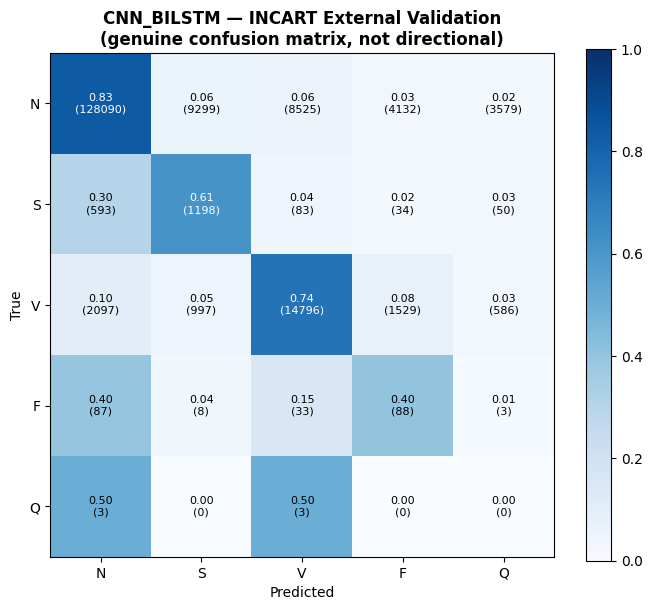

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\G_incart_confusion_matrix.png


In [9]:
# G8 — Plot the INCART confusion matrix
# ──────────────────────────────────────────────────────────────────────────

import itertools

fig, ax = plt.subplots(figsize=(7, 6))
cm_norm = incart_cm.astype(float) / np.maximum(incart_cm.sum(axis=1, keepdims=True), 1)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
labels = [AAMI_LABELS[k] for k in range(N_CLASSES)]
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(labels)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{MODEL_TO_VALIDATE.replace('_model.keras','').upper()} — INCART External Validation\n(genuine confusion matrix, not directional)",
             fontweight="bold")
for i, j in itertools.product(range(N_CLASSES), range(N_CLASSES)):
    ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({incart_cm[i,j]})", ha="center", va="center",
            fontsize=8, color="white" if cm_norm[i,j] > 0.5 else "black")
plt.tight_layout()

out = os.path.join(FIGS_DIR, "G_incart_confusion_matrix.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved {out}")

## G9 — MIT-BIH (DS2) vs. INCART — Side-by-Side Comparison

⚠ Could not exactly match model name 'CNN-BiLSTM' — using CNN (baseline) for comparison


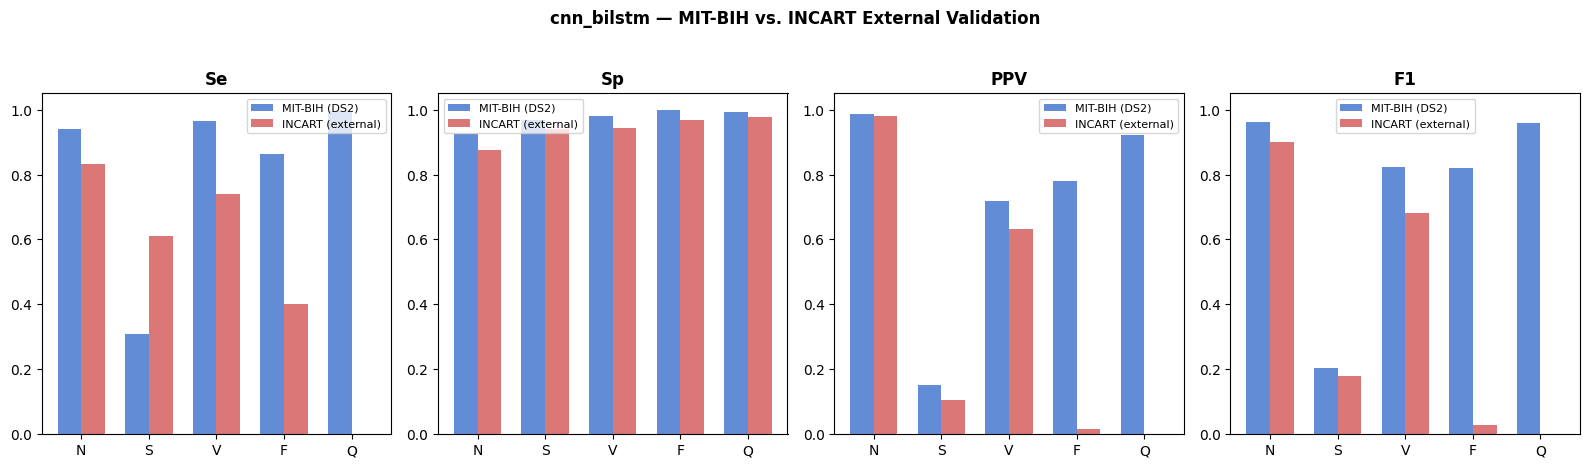

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\G_incart_vs_mitbih_comparison.png

Interpretation guide:
  • Performance drop on INCART vs MIT-BIH is EXPECTED and not itself a failure —
    different population, different hardware (12-lead Holter vs 2-lead ambulatory),
    different sampling rate (resampled from 257→360 Hz), different annotators.
  • What matters is whether the drop is graceful (a few points) or catastrophic
    (near-chance performance), and whether per-class patterns (e.g. weakest on S)
    are consistent with MIT-BIH — consistent weaknesses suggest the model learned
    genuine ECG structure; inconsistent collapse suggests MIT-BIH-specific overfitting.


In [10]:
# G9 — Compare this study's MIT-BIH DS2 test metrics against INCART external validation
# ──────────────────────────────────────────────────────────────────────────
# Loads the matching MIT-BIH metrics for the SAME model from Part E's saved CSV,
# so this is an apples-to-apples comparison: same model, two different datasets.

e_metrics_path = os.path.join(SAVE_DIR, "E_metrics_summary.csv")
if os.path.exists(e_metrics_path):
    mitbih_df_full = pd.read_csv(e_metrics_path)
    model_key = MODEL_TO_VALIDATE.replace("_model.keras", "").upper().replace("CNN_BILSTM", "CNN-BiLSTM").replace("BILSTM","BiLSTM")
    mitbih_df = mitbih_df_full[mitbih_df_full["Model"].str.upper().str.replace("-","_") ==
                                model_key.upper().replace("-","_")]
    if len(mitbih_df) == 0:
        mitbih_df = mitbih_df_full[mitbih_df_full["Model"] == mitbih_df_full["Model"].iloc[0]]
        print(f"⚠ Could not exactly match model name '{model_key}' — using {mitbih_df['Model'].iloc[0]} for comparison")

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    metrics_cls = ["Se", "Sp", "PPV", "F1"]
    x = np.arange(N_CLASSES)
    w = 0.35

    for ax, metric in zip(axes, metrics_cls):
        mit_vals = [mitbih_df.loc[mitbih_df["Class"]==AAMI_LABELS[k], metric].values[0]
                    if len(mitbih_df.loc[mitbih_df["Class"]==AAMI_LABELS[k]]) else 0
                    for k in range(N_CLASSES)]
        inc_vals = [incart_df.loc[incart_df["Class"]==AAMI_LABELS[k], metric].values[0]
                    for k in range(N_CLASSES)]

        ax.bar(x - w/2, mit_vals, width=w, label="MIT-BIH (DS2)", color="#4878CF", alpha=0.85)
        ax.bar(x + w/2, inc_vals, width=w, label="INCART (external)", color="#D65F5F", alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels([AAMI_LABELS[k] for k in range(N_CLASSES)])
        ax.set_title(metric, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)

    plt.suptitle(f"{MODEL_TO_VALIDATE.replace('_model.keras','')} — MIT-BIH vs. INCART External Validation",
                 fontweight="bold", y=1.03)
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, "G_incart_vs_mitbih_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved {out}")

    print("\nInterpretation guide:")
    print("  • Performance drop on INCART vs MIT-BIH is EXPECTED and not itself a failure —")
    print("    different population, different hardware (12-lead Holter vs 2-lead ambulatory),")
    print("    different sampling rate (resampled from 257→360 Hz), different annotators.")
    print("  • What matters is whether the drop is graceful (a few points) or catastrophic")
    print("    (near-chance performance), and whether per-class patterns (e.g. weakest on S)")
    print("    are consistent with MIT-BIH — consistent weaknesses suggest the model learned")
    print("    genuine ECG structure; inconsistent collapse suggests MIT-BIH-specific overfitting.")
else:
    print(f"⚠ {e_metrics_path} not found — run Part E first to generate MIT-BIH comparison metrics")
    print("  INCART-only results are still valid and saved above (G7/G8)")

## G10 — Summary

In [11]:
# G10 — Summary
# ──────────────────────────────────────────────────────────────────────────

print("="*62)
print("  Part G Complete — External Validation on INCART")
print("="*62)
print()
print(f"  Model validated     : {MODEL_TO_VALIDATE}")
print(f"  INCART beats tested : {len(y_incart):,}  (from {len(INCART_RECORDS)} records, 32 patients)")
print()
print(f"  Accuracy  : {incart_acc*100:.2f}%")
print(f"  Macro-F1  : {macro_f1:.4f}")
print(f"  Macro-AUC : {macro_auc:.4f}")
print()
print("  This IS genuine quantitative cross-dataset validation — INCART provides real")
print("  per-beat AAMI-mappable ground truth, unlike PTB-XL (Part F, F19), which could")
print("  only support a directional sanity check.")
print()
print("  Files saved:")
print("    G_incart_beats.npy / G_incart_labels.npy / G_incart_record_ids.npy")
print("    G_incart_proba.npy")
print("    G_incart_validation_metrics.csv   ← cite this alongside Table 2 in your paper")
print("    G_incart_confusion_matrix.png")
print("    G_incart_vs_mitbih_comparison.png")
print()
print("  Suggested paper framing:")
print('    "External validation was performed on the St. Petersburg INCART 12-lead')
print('     Arrhythmia Database [cite], which shares MIT-BIH\'s PhysioBank annotation')
print('     convention and was used to compute genuine per-class Se/Sp/PPV/F1 on data')
print('     entirely unseen during training (Table X)."')
print()
print("="*62)

  Part G Complete — External Validation on INCART

  Model validated     : cnn_bilstm_model.keras
  INCART beats tested : 175,813  (from 75 records, 32 patients)

  Accuracy  : 82.00%
  Macro-F1  : 0.3578
  Macro-AUC : 0.8614

  This IS genuine quantitative cross-dataset validation — INCART provides real
  per-beat AAMI-mappable ground truth, unlike PTB-XL (Part F, F19), which could
  only support a directional sanity check.

  Files saved:
    G_incart_beats.npy / G_incart_labels.npy / G_incart_record_ids.npy
    G_incart_proba.npy
    G_incart_validation_metrics.csv   ← cite this alongside Table 2 in your paper
    G_incart_confusion_matrix.png
    G_incart_vs_mitbih_comparison.png

  Suggested paper framing:
    "External validation was performed on the St. Petersburg INCART 12-lead
     Arrhythmia Database [cite], which shares MIT-BIH's PhysioBank annotation
     convention and was used to compute genuine per-class Se/Sp/PPV/F1 on data
     entirely unseen during training (Table X)